## Исследование данных о российском кинопрокате



Заказчик этого исследования — Министерство культуры Российской Федерации.  
Нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Попробовать ответить на вопрос, насколько такие фильмы интересны зрителю.  
Таблица **mkrf_movies** содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.  
title — название фильма;  
puNumber — номер прокатного удостоверения;  
show_start_date — дата премьеры фильма;  
type — тип фильма;  
film_studio — студия-производитель;  
production_country — страна-производитель;  
director — режиссёр;  
producer — продюсер;  
age_restriction — возрастная категория;  
refundable_support — объём возвратных средств государственной поддержки;  
nonrefundable_support — объём невозвратных средств государственной поддержки;  
financing_source — источник государственного финансирования;  
budget — общий бюджет фильма;  
ratings — рейтинг фильма на КиноПоиске;  
genres — жанр фильма.  
Таблица **mkrf_shows** содержит сведения о показах фильмов в российских кинотеатрах.  
puNumber — номер прокатного удостоверения;  
box_office — сборы в рублях.  

### Шаг 1. Импорты и чтение файлов. 


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

In [18]:
try:
    data = pd.read_csv('/datasets/mkrf_movies.csv')
    data2 = pd.read_csv('/datasets/mkrf_shows.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_movies.csv')
    data2 = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_shows.csv')

In [19]:
data.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [20]:
data2.head()

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [21]:
data['puNumber'] = pd.to_numeric(data['puNumber'], errors='coerce')
data['puNumber'] = data['puNumber'].fillna(0)
data['puNumber'] = data['puNumber'].astype(int)
data = data.merge(data2, on='puNumber', how='left')
data.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

**show_start_date** — дата премьеры фильма, тип колонки должен быть дататайм  
**refundable_support** — объём возвратных средств государственной поддержки имеет много пропусков  
**nonrefundable_support** — объём невозвратных средств государственной поддержки имеет много пропусков  
**financing_source** — источник государственного финансирования имеет много пропусков  
**budget** — общий бюджет фильма имеет много пропусков  
**ratings** — рейтинг фильма на КиноПоиске, тип колонки должен быть float  
**box_office** — сборы в рублях тоже имеет много пропусков

### Шаг 2. Предобработка данных

In [23]:
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format='%Y-%m-%dT%H:%M:%S')

**show_start_date** - должен быть тип данных дататайм  
**ratings** - должен быть тип данных float

In [24]:
data.isna().mean().sort_values(ascending = False)*100

refundable_support       95.565055
nonrefundable_support    95.565055
budget                   95.565055
financing_source         95.565055
box_office               57.814587
ratings                  13.304836
genres                   13.037670
producer                  7.587497
film_studio               0.240449
director                  0.120224
production_country        0.026717
title                     0.000000
puNumber                  0.000000
show_start_date           0.000000
type                      0.000000
age_restriction           0.000000
dtype: float64

В колонках **film_studio, production_country, director** пропуски состовляют менее 1%, поэтому мы их не учитываем  
В колонках **refundable_support, nonrefundable_support, financing_source** указывается только в том случаи есть есть гос поддержка у фильма  
Пропуски в колонке **budget** в тех же строчках что и в колонках гос финансирования

In [25]:
data['refundable_support'] = data['refundable_support'].fillna(0)
data['nonrefundable_support'] = data['nonrefundable_support'].fillna(0)
data['budget'] = data['budget'].fillna(0)
data['financing_source'] = data['financing_source'].fillna(0)
data['box_office'] = data['box_office'].fillna(0)

In [39]:
data.duplicated().sum()

0

In [40]:
data['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

In [41]:
data['production_country'] = data['production_country'].str.replace('ё', 'е').replace([', '],' - ', regex=True)
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР - Венгрия',
       'Германия-Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Новая Зеландия',
       'Канада - Франция - Испания', 'США-Германия',
       'США - Великобритания', 'Великобритания', 'США - Германия',
       'Франция - Мексика - США', 'Россия - Казахстан - США',
       'СССР - Швеция', 'СССР - Франция - Англия - Куба - ГДР',
       'Германия', 'Великобритания-США-Германия-КНР',
       'СССР - ЧССР - Западный Берлин - ПНР', 'СССР - Италия',
       'Гонконг - КНР', 'США - Франция',
       'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США-Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия-Великобритания-Германия', 'Чехия', 'США-Австралия',
       'СССР - Финляндия', 'США-Франция-Великобритания-Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
      

In [42]:
data['title'].duplicated().sum()

713

In [44]:
data['title'] = data['title'].drop_duplicates()

In [45]:
data['puNumber'].duplicated().sum()

1

In [34]:
data['puNumber'] = data['puNumber'].drop_duplicates()

В категориальных столбцах были обнаружены пробелы в начале или в конце строки

In [159]:
data['type'].str.strip()
data['film_studio'].str.strip()
data['production_country'].str.strip()
data['director'].str.strip()
data['producer'].str.strip()
data['genres'].str.strip()

0          боевик,драма,мелодрама
1                   драма,военный
2       фантастика,боевик,триллер
3       фантастика,боевик,триллер
4       фантастика,боевик,триллер
                  ...            
7481                          NaN
7482               боевик,триллер
7483                          NaN
7484                          NaN
7485              комедия,вестерн
Name: genres, Length: 7486, dtype: object

В колонках были обнаружены пробелы в начале или в конце строки

In [160]:
#data[data['budget']<data['refundable_support']+data['nonrefundable_support']]
for t in data['puNumber'].unique():
    data.loc[(data['puNumber'] == t) & (data['budget']==0), 'budget'] = \
    data.loc[(data['puNumber'] == t), 'refundable_support'] + data.loc[(data['puNumber'] == t), 'nonrefundable_support']
#print(data[data['budget']!=data['refundable_support']+data['nonrefundable_support']])

В столбце **budget** уже заложена сумма двух столбцов: **refundable_support** и **nonrefundable_support**

In [161]:
data['year'] = pd.DatetimeIndex(data['show_start_date']).year

In [162]:
def first_znach(name):
    try:
        if name.find(',') == (-1):
            return name
        else:
            index = name.find(',')
            return name[:index]
    except:
        pass

In [163]:
data['FIO'] = data['director'].apply(first_znach)
data['Janr'] = data['genres'].apply(first_znach)
#print(data.head(25))

In [177]:
table = data[data['budget'] != 0]
table['gos'] = (table['refundable_support'] + table['nonrefundable_support'])/table['budget']
print('В среднем государственная поддержка составляет '+'{:,.2%}'.format(table['gos'].mean()) + ' от общего бюджета фильма')

В среднем государственная поддержка составляет 54.21% от общего бюджета фильма: 


Без учета фильмов без гос поддержки

### Шаг 3. Исследовательский анализ данных


In [178]:
print(data.groupby('year')['box_office'].agg(['count']))
prokat = data[data['box_office']!=0]
prokat = prokat['box_office'].count()/data['box_office'].count()
print('{:,.2%}'.format(prokat) + ' составляют фильмы с указанной информацией о прокате в кинотеатрах')

      count
year       
2010    985
2011    622
2012    593
2013    630
2014    807
2015    705
2016    818
2017    505
2018    891
2019    930
41.86% составляют фильмы с указанной информацией о прокате в кинотеатрах


In [180]:
for t in data['year'].unique():
    prokat_years = data[data['year']==t]
    prokat_years = prokat_years[prokat_years['box_office']!=0]['box_office'].count()/prokat_years['box_office'].count()
    print(t, '{:,.2%}'.format(prokat_years) + ' составляют фильмы с указанной информацией о прокате в кинотеатрах')

2015 65.53% составляют фильмы с указанной информацией о прокате в кинотеатрах
2016 64.18% составляют фильмы с указанной информацией о прокате в кинотеатрах
2013 28.41% составляют фильмы с указанной информацией о прокате в кинотеатрах
2014 33.83% составляют фильмы с указанной информацией о прокате в кинотеатрах
2012 20.74% составляют фильмы с указанной информацией о прокате в кинотеатрах
2017 70.69% составляют фильмы с указанной информацией о прокате в кинотеатрах
2010 10.25% составляют фильмы с указанной информацией о прокате в кинотеатрах
2011 17.52% составляют фильмы с указанной информацией о прокате в кинотеатрах
2018 53.31% составляют фильмы с указанной информацией о прокате в кинотеатрах
2019 56.99% составляют фильмы с указанной информацией о прокате в кинотеатрах


В 2010 году больше всего фильмов, но меньше всего извесных данных (10%)  
Период с 2015 по 2017 год полнее всего представлен в данных

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

               sum
year              
2018 49668403134.3
2017 48563707217.5
2019 48425708779.6
2016 47866299741.9
2015 39497365196.4
2014  7444951859.2
2013    29799706.2
2011    14102765.0
2012     6955423.0
2010     2428654.0

Cумма сборов была минимальной
            sum
year           
2010  2428654.0

Cумма сборов была максимальной
               sum
year              
2018 49668403134.3


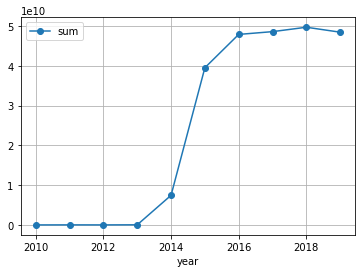

In [167]:
bar = data.groupby('year')['box_office'].agg(['sum'])
bar.plot(y='sum', style='-o', grid=True)
sum_sbor = data.groupby('year')['box_office'].agg(['sum'])
print(sum_sbor.sort_values('sum', ascending = False).to_string(formatters={'sum':'{:.12}'.format}))
print()
print("Cумма сборов была минимальной")
print(sum_sbor[sum_sbor['sum'] == sum_sbor['sum'].min()])
print()
print("Cумма сборов была максимальной")
print(sum_sbor[sum_sbor['sum'] == sum_sbor['sum'].max()].to_string(formatters={'sum':'{:.12}'.format}))

Cумма сборов была минимальной в 2010 году, из-за того что извесны данные только о 10% фильмов вышедших в этом году  

In [172]:
years = data.pivot_table(index='year', values='box_office', aggfunc=['mean','median'])
print(years)

              mean     median
        box_office box_office
year                         
2010  2.465639e+03        0.0
2011  2.267326e+04        0.0
2012  1.172921e+04        0.0
2013  4.730112e+04        0.0
2014  9.225467e+06        0.0
2015  5.602463e+07   739938.0
2016  5.851626e+07   479832.5
2017  9.616576e+07  2522174.0
2018  5.574456e+07   289040.0
2019  5.207065e+07   597710.0


Медина 2010 по 2014 год ровна 0, по причине того что нам извесно не более 30% о всех фильмах выходивших в каждом году  
2010 - 10%, 2011 - 17%, 2012 - 20%, 2013 - 28%, 2014 - 30%

Cобрали больше всего денег в прокате
                                          sum
age_restriction                              
«16+» - для детей старше 16 лет 76034733643.6


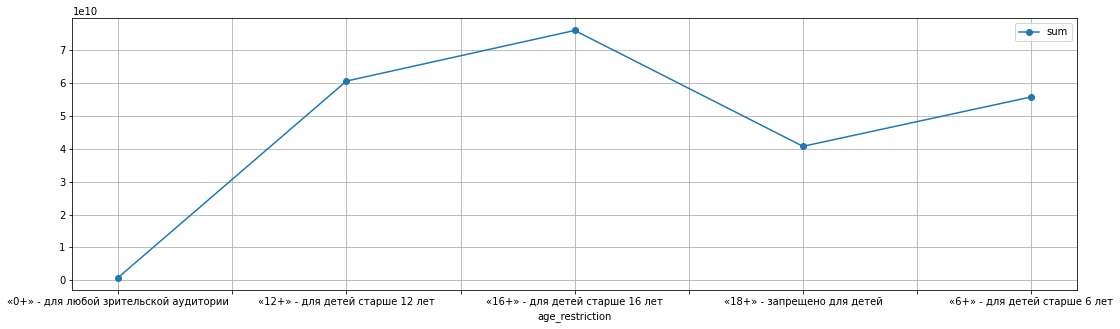

In [181]:
table = data[data['year']>=2015]
sr_sbor = table.groupby('age_restriction')['box_office'].agg(['sum'])
sr_sbor.plot(y= 'sum',style = 'o-' ,figsize = (18,5), grid= True )
sum_sbor = table.groupby('age_restriction')['box_office'].agg(['sum'])
print('Cобрали больше всего денег в прокате')
print(sum_sbor.sort_values('sum', ascending = False).head(1).to_string(formatters={'sum':'{:.12}'.format}))

Больше всего в прокате собрали фильмы категории "16+"

2015                                           sum
age_restriction                              
«12+» - для детей старше 12 лет 13616082008.9
2016                                           sum
age_restriction                              
«16+» - для детей старше 16 лет 16664548541.7
2017                                           sum
age_restriction                              
«16+» - для детей старше 16 лет 18745042900.1
2018                                           sum
age_restriction                              
«16+» - для детей старше 16 лет 16503602347.0
2019                                         sum
age_restriction                            
«6+» - для детей старше 6 лет 12852548650.9


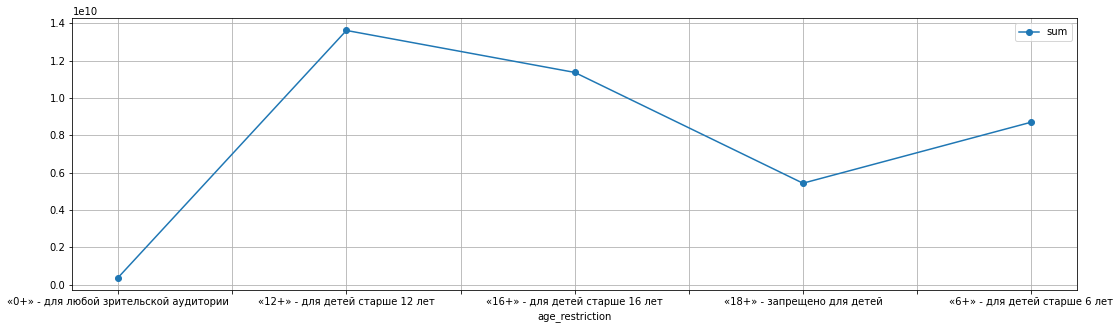

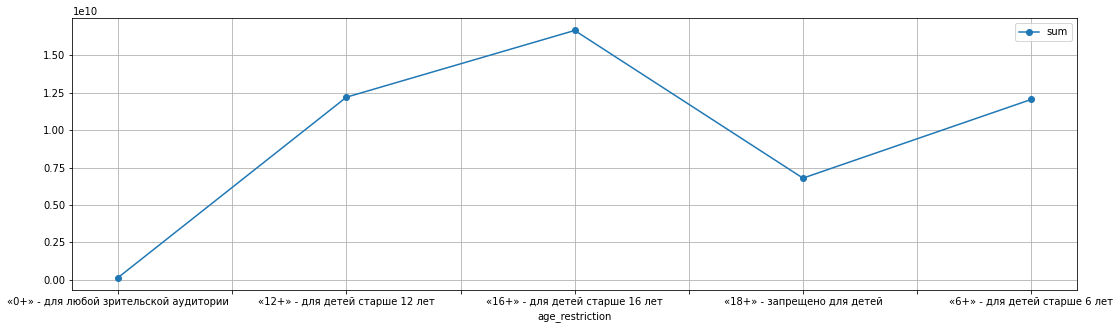

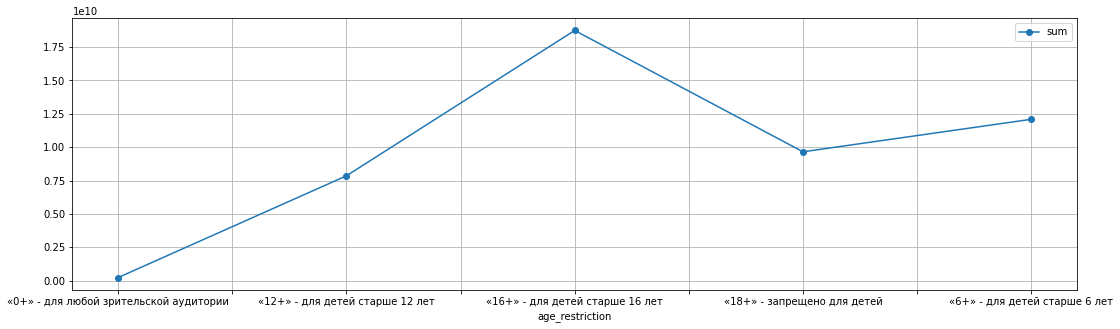

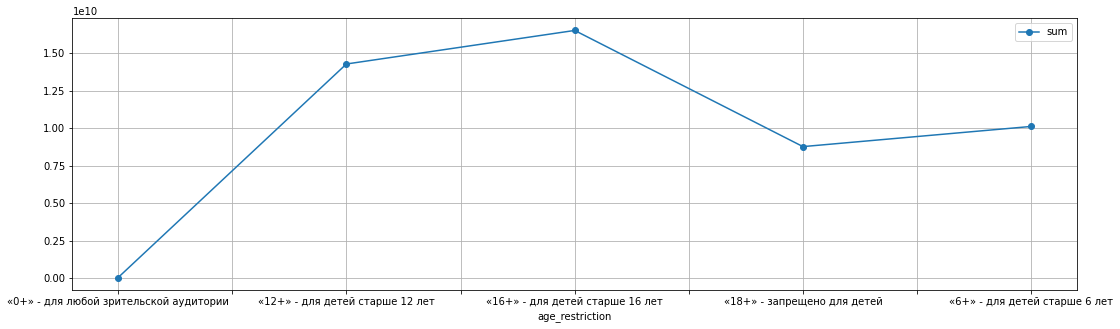

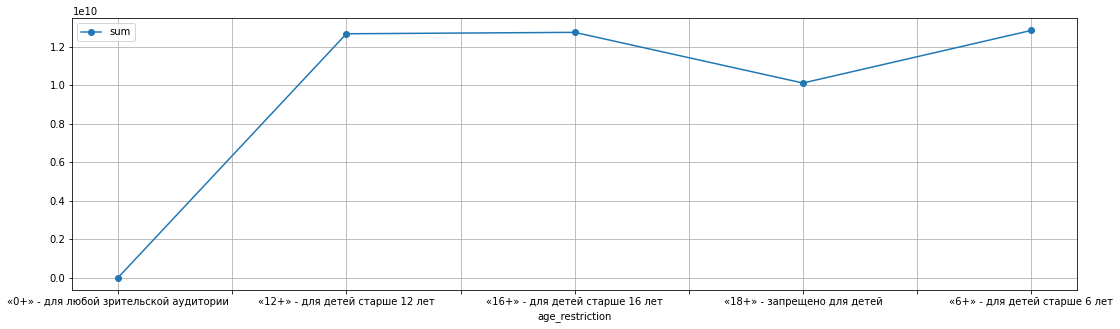

In [174]:
for t in table['year'].unique():
    sr_sbor_years = table[table['year']==t]
    sr_sbor_years = sr_sbor_years.groupby('age_restriction')['box_office'].agg(['sum'])
    print(t, sr_sbor_years[sr_sbor_years['sum']==sr_sbor_years['sum'].max()].to_string(formatters={'sum':'{:.12}'.format}))
    sr_sbor_years.plot(y= 'sum',style = 'o-' ,figsize = (18,5), grid= True )

Картина практически не меняется из года в год  
с 2016 по 2018 год лидируют фильмы "16+", скорее всего выходила какая-то трилогия или франшаза для подростков  
в 2015 году лидировали фильмы "12+" семейные фильмы в каждом году были в тройке лидеров  
в 2019 году лидерами стали фильмы "6+", совсем маленький разрыв между категориями "16+", "12+", "6+"

### Шаг 4. Исследование фильмов, которые получили государственную поддержку


In [175]:
data_gos = data[data['budget'] != 0]
print('В среднем на фильм гос-во выделяет ', (data_gos['refundable_support'] + data_gos['nonrefundable_support']).mean())
okupaemost = (data_gos['budget'] > (data_gos['refundable_support'] + data_gos['nonrefundable_support'])).count()/data_gos['budget'].count()
print('Окупаемость '+'{:,.2%}'.format(okupaemost))
print('Средний рейтинг '+'{:,.2}'.format(data_gos['ratings'].mean()))
data_gos.groupby('Janr')['ratings'].mean().sort_values(ascending = False)

В среднем на фильм гос-во выделяет  60845446.72289157
Окупаемость 100.00%
Средний рейтинг 6.0


Janr
криминал       7.500000
детский        7.125000
спорт          6.933333
биография      6.900000
детектив       6.760000
боевик         6.583333
мюзикл         6.550000
военный        6.466667
драма          6.391304
фэнтези        6.090909
мелодрама      5.953333
приключения    5.871429
фантастика     5.820000
мультфильм     5.800000
триллер        5.706667
реальное ТВ    5.600000
комедия        5.514865
семейный       5.414286
история        5.350000
ужасы          5.200000
Name: ratings, dtype: float64

Лучшим зрители признали жанр "Криминал" и "Детский"

### Шаг 5. Общий вывод

**Согласно проведенному исследованию, я получил следующие результаты:**  
- Среди фильмов с государственной поддержкой, государственная поддержка состовляет в среднем 54% от бюджета фильма  
- Сумма сборов по годам:  
    2018 - 49 668 403 134.3  
    2017 - 48 563 707 217.5  
    2019 - 48 425 708 779.6  
    2016 - 47 866 299 741.9  
    2015 - 39 497 365 196.4  
    С 2010 и до 2014 года недостаточно данных о прокате фильмов, но по имеющимся данным получилось следующее:  
    2014 - 7 444 951 859.2  
    2013 - 29 799 706.2  
    2011 - 14 102 765.0  
    2012 - 6 955 423.0  
    2010 - 2 428 654.0  
- Cобрали больше всего денег в прокате фильмы возростной категории «16+» в периуд 2015 оп 2019 год - 76 034 733 643.6  
    2015  
    Лидировали фильмы категории «12+» ,собрали сумму проката - 13 616 082 008.9, с небольшим отрывом от категории «16+»  
    2016  
    Лидировали фильмы категории «16+» ,собрали сумму проката - 16 664 548 541.7, с отрывом от категории «12+»  
    2017  
    Лидировали фильмы категории «16+» ,собрали сумму проката - 18 745 042 900.1, с большим отрывом от других категорий  
    2018  
    Лидировали фильмы категории «16+» ,собрали сумму проката - 16 503 602 347.0, с небольшим отрывом от категории «12+»  
    2019  
    Лидировали фильмы категории «6+» ,собрали сумму проката - 12 852 548 650.9, практически без отрыва от категорий «12+» и «16+»  
- В среднем на фильм государственная поддержка состовляет - 60 845 446.72  
- Средний рейтинг таких фильмов состовляет 6.0  
- По жанрам средний рейтинг следующий:  
    криминал    7.5  
    детский     7.1  
    спорт       6.9  
    биография   6.9  
    детектив    6.8  
    боевик      6.6  
    мюзикл      6.6  
    военный     6.5  
    драма       6.4  
    фэнтези     6.0  
    мелодрама   6.0   
    приключения 5.9  
    фантастика  5.8  
    мультфильм  5.8  
    триллер     5.7  
    реальное ТВ 5.6  
    комедия     5.5  
    семейный    5.4  
    история     5.4  
    ужасы       5.2  